/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2546/3331851187.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit



DEUTSCH-JOZSA ALGORITHM - BALANCED PARITY FUNCTION

QUANTUM CIRCUIT
----------------------------------------------------------------------
     ┌───┐     ┌─────────┐┌───┐
q_0: ┤ H ├─────┤0        ├┤ H ├
     ├───┤     │         │├───┤
q_1: ┤ H ├─────┤1        ├┤ H ├
     ├───┤     │  Parity │├───┤
q_2: ┤ H ├─────┤2        ├┤ H ├
     ├───┤┌───┐│         │└───┘
q_3: ┤ X ├┤ H ├┤3        ├─────
     └───┘└───┘└─────────┘     

MEASUREMENT RESULTS
----------------------------------------------------------------------
Number of input qubits : 3
Number of shots        : 1000
000 count              : 0
Non-zero count         : 1000
Most probable output   : 111
P(000)                 : 0.0000
P(non-zero)            : 1.0000
Function classification : BALANCED

PARITY FUNCTION
----------------------------------------------------------------------
f(x0, x1, x2) = x0 XOR x1 XOR x2

Truth Table:
Input       Function Value
--------------------------
000          0
001          1
010          1
011 

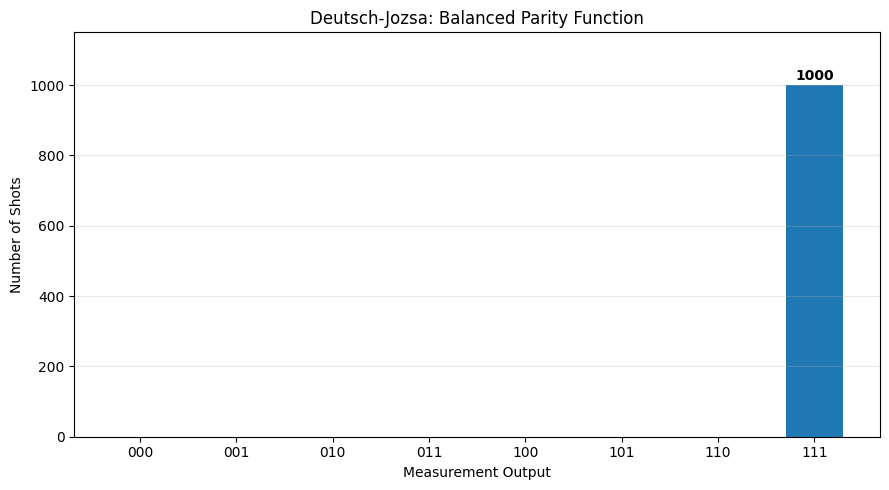

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1000

# ---------------------------------------------------------
# BALANCED PARITY FUNCTION
# f(x0, x1, x2) = x0 XOR x1 XOR x2
# 3 INPUT QUBITS + 1 ANCILLA
# ---------------------------------------------------------

n = 3

# ---------------------------------------------------------
# CREATE BALANCED PARITY ORACLE
# ---------------------------------------------------------

oracle = QuantumCircuit(
    n + 1,
    name="Parity"
)

# Parity function:
# f(x0, x1, x2) = x0 XOR x1 XOR x2

for qubit in range(n):
    oracle.cx(
        qubit,
        n
    )

oracle_gate = oracle.to_gate()

# ---------------------------------------------------------
# BUILD DEUTSCH-JOZSA CIRCUIT
# ---------------------------------------------------------

qc = QuantumCircuit(
    n + 1
)

# Put input qubits into superposition
for qubit in range(n):
    qc.h(qubit)

# Prepare ancilla in |1>
qc.x(n)

# Convert ancilla to |-> state
qc.h(n)

# Apply balanced oracle
qc.append(
    oracle_gate,
    list(range(n + 1))
)

# Apply final Hadamard gates
for qubit in range(n):
    qc.h(qubit)

# ---------------------------------------------------------
# CALCULATE STATEVECTOR
# ---------------------------------------------------------

state = Statevector.from_instruction(
    qc
)

probabilities = state.probabilities()

# ---------------------------------------------------------
# COMBINE ANCILLA PROBABILITIES
# ---------------------------------------------------------

input_probabilities = np.zeros(
    2 ** n
)

for index, probability in enumerate(
    probabilities
):

    input_value = index % (2 ** n)

    input_probabilities[input_value] += probability

# Normalize to avoid floating-point errors
input_probabilities = (
    input_probabilities
    / np.sum(input_probabilities)
)

# ---------------------------------------------------------
# SIMULATE MEASUREMENTS
# ---------------------------------------------------------

rng = np.random.default_rng(42)

samples = rng.choice(
    np.arange(2 ** n),
    size=SHOTS,
    p=input_probabilities
)

counts = np.bincount(
    samples,
    minlength=2 ** n
)

# ---------------------------------------------------------
# FIND ZERO AND NON-ZERO RESULTS
# ---------------------------------------------------------

zero_count = int(
    counts[0]
)

non_zero_count = int(
    np.sum(counts[1:])
)

# Most probable output
most_probable = int(
    np.argmax(input_probabilities)
)

output = format(
    most_probable,
    f"0{n}b"
)

# ---------------------------------------------------------
# CLASSIFICATION
# ---------------------------------------------------------

if zero_count == SHOTS:
    classification = "CONSTANT"
else:
    classification = "BALANCED"

# ---------------------------------------------------------
# OUTPUT
# ---------------------------------------------------------

print(
    "\nDEUTSCH-JOZSA ALGORITHM - BALANCED PARITY FUNCTION"
)

print(
    "=" * 70
)

print("\nQUANTUM CIRCUIT")

print(
    "-" * 70
)

print(
    qc.draw()
)

print("\nMEASUREMENT RESULTS")

print(
    "-" * 70
)

print(
    f"Number of input qubits : {n}"
)

print(
    f"Number of shots        : {SHOTS}"
)

print(
    f"000 count              : {zero_count}"
)

print(
    f"Non-zero count         : {non_zero_count}"
)

print(
    f"Most probable output   : {output}"
)

print(
    f"P(000)                 : "
    f"{zero_count / SHOTS:.4f}"
)

print(
    f"P(non-zero)            : "
    f"{non_zero_count / SHOTS:.4f}"
)

print(
    f"Function classification : "
    f"{classification}"
)

# ---------------------------------------------------------
# PARITY FUNCTION DETAILS
# ---------------------------------------------------------

print("\nPARITY FUNCTION")

print(
    "-" * 70
)

print(
    "f(x0, x1, x2) = x0 XOR x1 XOR x2"
)

print(
    "\nTruth Table:"
)

print(
    "Input       Function Value"
)

print(
    "--------------------------"
)

for x in range(2 ** n):

    bits = format(
        x,
        f"0{n}b"
    )

    value = (
        bits.count("1") % 2
    )

    print(
        f"{bits}          {value}"
    )

# ---------------------------------------------------------
# THEORETICAL RESULT
# ---------------------------------------------------------

print("\nTHEORETICAL RESULT")

print(
    "-" * 70
)

print(
    "Expected Deutsch-Jozsa output : 111"
)

print(
    "Expected result                : NON-ZERO"
)

if classification == "BALANCED":

    print(
        "Verification                  : "
        "CORRECT - BALANCED FUNCTION"
    )

else:

    print(
        "Verification                  : "
        "INCORRECT"
    )

# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------

labels = [
    "000",
    "001",
    "010",
    "011",
    "100",
    "101",
    "110",
    "111"
]

values = counts

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.bar(
    labels,
    values,
    width=0.6
)

ax.set_title(
    "Deutsch-Jozsa: Balanced Parity Function"
)

ax.set_xlabel(
    "Measurement Output"
)

ax.set_ylabel(
    "Number of Shots"
)

ax.set_ylim(
    0,
    SHOTS * 1.15
)

for bar, value in zip(
    bars,
    values
):

    if value > 0:

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            value + 15,
            str(value),
            ha="center",
            fontweight="bold"
        )

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()